# AAV5 -- Plafond de bruit sur `viab` (attenuation correction + split-half empirique)

Suite à la discussion sur le ProfileMLP `viab` (r held-out ~0.2-0.29 selon le CSV, cf.
`AAV5_SEL_profile_model_before_after_sorting.ipynb`) et au constat d'`AAV5_viab_fitting_protocol.ipynb`
(le protocole simulé perd la bimodalité réelle à profondeur réaliste `D=1e6`) : est-ce qu'on est
face à un **plafond de bruit** (données trop bruitées pour aller plus loin) ou à une **limite de
méthode** (le modèle/le fit laisse du signal sur la table) ?

Deux estimations indépendantes du plafond de corrélation atteignable par n'importe quel modèle
(même un dénoiseur parfait) contre la cible `viab` (`log2(virus/plasmide)`, `AAV5_organoides_sorted.csv`) :

1. **Analytique** -- via l'approximation delta de Poisson : la variance du bruit de comptage sur
   le log ratio est `1/(n_virus+eps) + 1/(n_plasmide+eps)`, exactement la même forme que le poids
   inverse-variance `w = 1/(...)` déjà utilisé pour la régression de Potts dans ce projet (`w` EST
   `1/var(bruit)`). Fiabilité `rho = 1 - var(bruit)/var(cible observée)` ; formule classique de
   "correction for attenuation" : `corr(vrai signal, cible observée) = sqrt(rho)` -- le plafond
   qu'un dénoiseur PARFAIT peut atteindre contre la cible bruitée à une seule mesure.
2. **Empirique, sans hypothèse de forme** -- thinning binomial : scinder chaque comptage brut en
   deux via `Binomial(n, 0.5)`. Les deux moitiés partagent EXACTEMENT le même vrai ratio sous-jacent
   (zéro variation biologique, pur sous-échantillonnage). Leur corrélation sous-estime la fiabilité
   pleine profondeur (chaque moitié a environ 2x moins de comptage donc 2x plus de bruit) --
   corrigée par la formule de Spearman-Brown (prophétie split-half, standard en psychométrie/théorie
   de la mesure) pour revenir à la fiabilité pleine profondeur.

Hors périmètre ici (déjà écarté en discussion) : une loss Poisson/Multinomial comme piste
d'amélioration du modèle -- ce notebook teste UNIQUEMENT le plafond de bruit, pas de nouvelle
méthode d'entraînement.

**Pas exécuté automatiquement** -- léger (pandas/numpy sur un CSV déjà filtré, pas d'entraînement),
mais laissé pour que tu le lances toi-même.


In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"   # avant tout import jax (via analysisV1)
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
LIB = _root / "lib"
from analysisV1 import AA_LABELS, pearson

CSV = Path("AAV5_organoides_sorted.csv")
if not CSV.exists():
    CSV = _root / "notebooks/notebooks/Selectivity/AAV5/AAV5_organoides_sorted.csv"
assert CSV.exists(), CSV

viab_col = "log2_enrichissement_virus_sur_plasmide"
use_cols = ["sequence", "compte_plasmide", "compte_virus", viab_col]
dtypes = {"sequence": "string", "compte_plasmide": "float32", "compte_virus": "float32", viab_col: "float32"}
df = pd.read_csv(CSV, usecols=use_cols, dtype=dtypes)
df["sequence"] = df["sequence"].astype("string")
print(df.shape)
df.head()


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(3822400, 4)


,sequence,compte_plasmide,compte_virus,log2_enrichissement_virus_sur_plasmide
0,TEVDRMT,36.5,0.5,-4.928953
1,TGRSDAQ,10.0,8.5,1.026406
2,PIRINSN,14.5,1.0,-2.597110
3,GNLRVIL,35.5,10.0,-0.566948
4,MNTEPRM,42.0,9.0,-0.961521


## 1. Cible recalculée (`eps=0.5`)

Convention projet : jamais `+1`. Sanity check contre la colonne fournie par le CSV.

In [2]:
EPS = 0.5   # convention projet -- jamais +1 (cf. CLAUDE.md)

plasmid = df["compte_plasmide"].to_numpy(np.float64)
virus   = df["compte_virus"].to_numpy(np.float64)

target_ln   = np.log((virus + EPS) / (plasmid + EPS))   # base naturelle -- pour le calcul de plafond
target_log2 = target_ln / np.log(2)                       # base log2 -- pour comparer aux poids Potts déjà fittés

target_csv = df[viab_col].to_numpy(np.float64)
r_vs_csv = pearson(target_log2, target_csv)
print(f"n = {len(df):,}")
print(f"r(cible recalculée eps=0.5, colonne CSV fournie) = {r_vs_csv:+.4f}  "
      f"(attendu ~0.998, cf. AAV5_SEL_viab_potts_regression_eps05.ipynb)")


n = 3,822,400
r(cible recalculée eps=0.5, colonne CSV fournie) = +0.9977  (attendu ~0.998, cf. AAV5_SEL_viab_potts_regression_eps05.ipynb)


## 2. Plafond analytique -- correction d'atténuation (Poisson delta-method)

In [3]:
# Var(ln X) ~= 1/lambda pour X ~ Poisson(lambda) (méthode delta) -- même forme que le poids
# inverse-variance déjà utilisé pour la régression de Potts : w = 1/(1/(n_num+eps)+1/(n_den+eps))
# est EXACTEMENT 1/noise_var sur le log ratio, en base naturelle.
noise_var_ln = 1.0 / (virus + EPS) + 1.0 / (plasmid + EPS)

mean_noise_var = noise_var_ln.mean()
observed_var   = target_ln.var()
rho            = 1.0 - mean_noise_var / observed_var
ceiling_r      = np.sqrt(max(rho, 0.0))

print(f"var(bruit de comptage), moyenne sur {len(df):,} variants : {mean_noise_var:.4f}")
print(f"var(cible observée)                                     : {observed_var:.4f}")
print(f"fiabilité rho = 1 - bruit/observé                       : {rho:.4f}")
print(f"plafond analytique sqrt(rho) (dénoiseur parfait vs cible observée) : {ceiling_r:.4f}")

# rho est invariant au changement de base de log -- vérification
noise_var_log2 = noise_var_ln / (np.log(2) ** 2)
rho_log2 = 1.0 - noise_var_log2.mean() / target_log2.var()
assert abs(rho_log2 - rho) < 1e-9, (rho_log2, rho)
print("(vérifié : rho identique en base log2, comme attendu -- rho est sans dimension)")


var(bruit de comptage), moyenne sur 3,822,400 variants : 0.3145
var(cible observée)                                     : 2.4125
fiabilité rho = 1 - bruit/observé                       : 0.8696
plafond analytique sqrt(rho) (dénoiseur parfait vs cible observée) : 0.9325
(vérifié : rho identique en base log2, comme attendu -- rho est sans dimension)


## 3. Plafond empirique -- thinning binomial + correction Spearman-Brown

Aucune hypothèse sur la forme du bruit (contrairement à la section 2, qui suppose l'approximation delta de Poisson).

In [4]:
def split_half_r(plasmid, virus, eps, rng):
    p_a = rng.binomial(plasmid.astype(np.int64), 0.5).astype(np.float64)
    p_b = plasmid - p_a
    v_a = rng.binomial(virus.astype(np.int64), 0.5).astype(np.float64)
    v_b = virus - v_a
    t_a = np.log((v_a + eps) / (p_a + eps))
    t_b = np.log((v_b + eps) / (p_b + eps))
    return pearson(t_a, t_b)

K = 30
rng = np.random.default_rng(0)
r_splits = np.array([split_half_r(plasmid, virus, EPS, rng) for _ in range(K)])
rho_half = r_splits.mean()

# Spearman-Brown (prophétie split-half) : chaque moitié a ~2x moins de comptage -> ~2x plus de
# bruit -> corr(moitié A, moitié B) sous-estime la fiabilité réelle à pleine profondeur.
rho_full_empirical = 2 * rho_half / (1 + rho_half)
ceiling_r_empirical = np.sqrt(max(rho_full_empirical, 0.0))

print(f"corr(moitié A, moitié B), moyenne sur {K} tirages : {rho_half:.4f} +/- {r_splits.std():.4f}")
print(f"fiabilité pleine profondeur (Spearman-Brown)      : {rho_full_empirical:.4f}")
print(f"plafond empirique sqrt(rho_full)                  : {ceiling_r_empirical:.4f}")
print(f"(à comparer au plafond analytique de la section 2 : {ceiling_r:.4f})")


corr(moitié A, moitié B), moyenne sur 30 tirages : 0.8444 +/- 0.0001
fiabilité pleine profondeur (Spearman-Brown)      : 0.9156
plafond empirique sqrt(rho_full)                  : 0.9569
(à comparer au plafond analytique de la section 2 : 0.9325)


## 4. Où se situe le fit Potts existant par rapport à ce plafond ?

Les poids `aav5_{F,J}_viab_potts_sorted_unreg.npy` / `..._eps05_...` ont été fittés sur ce même CSV dans `obsolete/AAV5_SEL_potts_regression.ipynb` / `AAV5_SEL_viab_potts_regression_eps05.ipynb` -- r held-out déjà validés : +0.204 / +0.202.

In [5]:
F_unreg = np.load(LIB / "aav5_F_viab_potts_sorted_unreg.npy")
J_unreg = np.load(LIB / "aav5_J_viab_potts_sorted_unreg.npy")
F_eps05 = np.load(LIB / "aav5_F_viab_eps05_potts_sorted_unreg.npy")
J_eps05 = np.load(LIB / "aav5_J_viab_eps05_potts_sorted_unreg.npy")

L, A = 7, 20
lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i
seq_matrix = lut[np.frombuffer("".join(df["sequence"]).encode("ascii"), np.uint8)].reshape(len(df), L)

def score_FJ(seq, F, J):
    F, J = np.asarray(F), np.asarray(J)
    Fp = F[seq, np.arange(L)].sum(axis=1).astype(np.float64)
    Jp = np.zeros(len(seq), dtype=np.float64)
    for i in range(L):
        for j in range(i + 1, L):
            Jp += J[i, j, seq[:, i], seq[:, j]]
    return Fp + Jp

score_unreg = score_FJ(seq_matrix, F_unreg, J_unreg)
score_eps05 = score_FJ(seq_matrix, F_eps05, J_eps05)
r_insample_unreg = pearson(score_unreg, target_log2)
r_insample_eps05 = pearson(score_eps05, target_log2)

print("ATTENTION : ces 2 derniers r sont calculés sur les MÊMES variants qui ont servi (en partie) à")
print("fitter ces poids -- in-sample, optimiste. Référence honnête = les r held-out déjà validés.\n")

rows = [
    ("Potts (LAM=0, cible CSV fournie)  -- held-out validé", 0.204),
    ("Potts (LAM=0, cible eps=0.5 recalculée) -- held-out validé", 0.202),
    ("Potts (LAM=0, cible CSV fournie)  -- in-sample (ce notebook)", r_insample_unreg),
    ("Potts (LAM=0, cible eps=0.5 recalculée) -- in-sample (ce notebook)", r_insample_eps05),
    ("PLAFOND analytique sqrt(rho)  (section 2)", ceiling_r),
    ("PLAFOND empirique sqrt(rho) split-half Spearman-Brown  (section 3)", ceiling_r_empirical),
]
tbl = pd.DataFrame(rows, columns=["méthode", "r"]).set_index("méthode")
print(tbl.to_string(float_format=lambda x: f"{x:+.3f}"))

R_HELD_OUT = 0.204
best_ceiling = max(ceiling_r, ceiling_r_empirical)
frac = R_HELD_OUT / best_ceiling if best_ceiling > 0 else float("nan")
print(f"\nr held-out actuel / plafond estimé = {frac:.1%}")
if frac >= 0.85:
    print("-> le modèle est déjà proche du plafond de bruit : peu de marge, le problème est bien les données.")
elif frac >= 0.5:
    print("-> marge intermédiaire : une partie du signal extractible reste probablement sur la table.")
else:
    print("-> écart important au plafond : le modèle/la méthode de fit laisse du signal extractible de côté.")


ATTENTION : ces 2 derniers r sont calculés sur les MÊMES variants qui ont servi (en partie) à
fitter ces poids -- in-sample, optimiste. Référence honnête = les r held-out déjà validés.

                                                                        r
méthode                                                                  
Potts (LAM=0, cible CSV fournie)  -- held-out validé               +0.204
Potts (LAM=0, cible eps=0.5 recalculée) -- held-out validé         +0.202
Potts (LAM=0, cible CSV fournie)  -- in-sample (ce notebook)       +0.208
Potts (LAM=0, cible eps=0.5 recalculée) -- in-sample (ce notebook) +0.203
PLAFOND analytique sqrt(rho)  (section 2)                          +0.933
PLAFOND empirique sqrt(rho) split-half Spearman-Brown  (section 3) +0.957

r held-out actuel / plafond estimé = 21.3%
-> écart important au plafond : le modèle/la méthode de fit laisse du signal extractible de côté.


## 5. Compromis profondeur de comptage / plafond -- où filtrer si on veut plus de signal ?

Même levier que `AAV2_viab_top10k_potts_protocol_mlp.ipynb` (garder les variants les mieux mesurés) mais quantifié directement en plafond de corrélation plutôt qu'à tâtons.

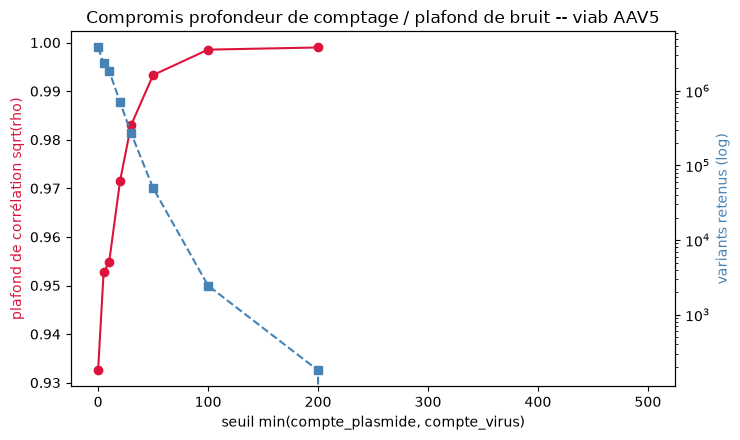

,"min(plasmide,virus) >=",n_variants,rho,plafond sqrt(rho)
0,0,3822400,0.869626,0.932537
1,5,2350151,0.907663,0.952714
2,10,1865109,0.911579,0.954766
3,20,706230,0.943915,0.971553
4,30,271492,0.966321,0.983016
5,50,49803,0.986676,0.993316
6,100,2452,0.997103,0.998550
7,200,179,0.997989,0.998994
8,500,0,NaN,NaN


In [6]:
def ceiling_at_threshold(min_count):
    mask = (plasmid >= min_count) & (virus >= min_count)
    n = int(mask.sum())
    if n < 100:
        return n, np.nan, np.nan
    t = target_ln[mask]
    nv = noise_var_ln[mask]
    rho_t = 1.0 - nv.mean() / t.var()
    return n, rho_t, np.sqrt(max(rho_t, 0.0))

thresholds = [0, 5, 10, 20, 30, 50, 100, 200, 500]
rows = [(t, *ceiling_at_threshold(t)) for t in thresholds]
sweep = pd.DataFrame(rows, columns=["min(plasmide,virus) >=", "n_variants", "rho", "plafond sqrt(rho)"])

fig, ax1 = plt.subplots(figsize=(7.5, 4.5))
ax2 = ax1.twinx()
ax1.plot(sweep["min(plasmide,virus) >="], sweep["plafond sqrt(rho)"], "o-", color="crimson", label="plafond sqrt(rho)")
ax2.plot(sweep["min(plasmide,virus) >="], sweep["n_variants"], "s--", color="steelblue", label="n variants")
ax2.set_yscale("log")
ax1.set_xlabel("seuil min(compte_plasmide, compte_virus)")
ax1.set_ylabel("plafond de corrélation sqrt(rho)", color="crimson")
ax2.set_ylabel("variants retenus (log)", color="steelblue")
ax1.set_title("Compromis profondeur de comptage / plafond de bruit -- viab AAV5")
fig.tight_layout()
plt.show()
sweep


## Lecture

- Si le r held-out actuel (`~0.20`) est déjà proche des deux plafonds calculés en §2/§3 (analytique
  et empirique devraient être proches l'un de l'autre si l'approximation Poisson tient) : les
  données sont bien le facteur limitant à ce niveau de comptage -- la piste la plus rentable est
  alors la §5 (filtrer/pondérer vers les variants mieux mesurés, comme `sel_org2∩org3` ou
  `AAV2_viab_top10k` l'ont déjà montré ailleurs dans le projet), pas une architecture de modèle
  plus grosse.
- Si le r held-out est nettement en dessous des plafonds : il reste du signal extractible que le
  fit Potts / le ProfileMLP actuel ne capture pas -- vaut la peine de creuser côté méthode
  (pondération inverse-variance winsorisée, loss de ranking -- cf. discussion) avant de conclure
  "trop bruité".